In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.outliers_influence import variance_inflation_factor

master = pd.read_csv(
    "../data/processed/listing_master.csv"
)

master.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,listing_id,total_reviews,first_review_y,last_review_y,median_price,listing_density,average_rating,host_tenure_years,review_frequency,price_per_bedroom
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,13913.0,55.0,2010-08-18,2025-08-21,141.0,5036,4.724966,16.610959,3.311067,70.0
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,15400.0,97.0,2009-12-21,2025-04-05,225.0,6401,4.714067,16.558904,5.857876,149.0
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,17402.0,56.0,2011-03-21,2024-02-19,220.0,11385,4.665023,16.476712,3.398736,137.0
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,24328.0,95.0,2010-11-15,2025-07-05,140.0,4965,4.787750,16.745205,5.673266,NaN
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,36274.0,15.0,2011-03-20,2025-09-06,127.0,7469,4.680864,16.084932,0.932550,210.0


5.1  Hypothesis Testing 

In [ ]:
#H1
entire = master[
    master["room_type"] == "Entire Home/Apt"
]["price"]

private = master[
    master["room_type"] == "Private Room"
]["price"]

In [5]:
#Assumption Check
stats.shapiro(
    entire.sample(
        min(5000, len(entire))
    )
)

ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [6]:
#Welch T-Test
t_stat, p_value = stats.ttest_ind(
    entire,
    private,
    equal_var=False
)

print(t_stat)
print(p_value)

nan
nan


In [7]:
#Cohen's D
mean_diff = (
    entire.mean()
    -
    private.mean()
)

pooled_std = np.sqrt(
    (
        entire.std()**2
        +
        private.std()**2
    ) / 2
)

cohens_d = (
    mean_diff
    /
    pooled_std
)

print(cohens_d)

0.04097175452862177


In [8]:
#H2 Superhost vs Non-Superhost Ratings
superhost = master[
    master["host_is_superhost"] == "t"
]["review_scores_rating"]

non_superhost = master[
    master["host_is_superhost"] == "f"
]["review_scores_rating"]

In [9]:
#T-Test
t_stat, p_value = stats.ttest_ind(
    superhost,
    non_superhost,
    equal_var=False
)

print(t_stat)
print(p_value)

69.89862681841818
0.0


In [10]:
#Cohen D
cohens_d = (
    superhost.mean()
    -
    non_superhost.mean()
) / np.sqrt(
    (
        superhost.std()**2
        +
        non_superhost.std()**2
    ) / 2
)

print(cohens_d)

0.4430230605450019


In [11]:
#H3  More Than 10 Reviews vs Less Than 10
high_reviews = master[
    master["number_of_reviews"] > 10
]["price"]

low_reviews = master[
    master["number_of_reviews"] <= 10
]["price"]

In [12]:
#T-Test
t_stat, p_value = stats.ttest_ind(
    high_reviews,
    low_reviews,
    equal_var=False
)

print(t_stat)
print(p_value)

nan
nan


In [13]:
#Effect Size
cohens_d = (
    high_reviews.mean()
    -
    low_reviews.mean()
) / np.sqrt(
    (
        high_reviews.std()**2
        +
        low_reviews.std()**2
    ) / 2
)

print(cohens_d)

-0.020099479290933846


In [14]:
#H4  Neighbourhood Price Differences (ANOVA)
top_n = (
    master["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
    .index
)

anova_df = master[
    master["neighbourhood_cleansed"]
    .isin(top_n)
]

In [15]:
#ANOVA
model = ols(
    "price ~ C(neighbourhood_cleansed)",
    data=anova_df
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
C(neighbourhood_cleansed),3.036332e+08,9.0,1.093901,0.363199
Residual,1.216894e+12,39457.0,NaN,NaN


In [17]:
#Eta Squared

eta_sq = (
    anova_table.loc["C(neighbourhood_cleansed)", "sum_sq"]
    / anova_table["sum_sq"].sum()
)

print(f"Eta Squared: {eta_sq:.6f}")

Eta Squared: 0.000249


In [18]:
#H5 Weekend vs Weekday Prices
calendar = pd.read_csv(
    "../data/processed/calendar_clean.csv"
)

In [20]:
calendar["date"] = pd.to_datetime(
    calendar["date"]
)

calendar["price"] = (
    calendar["price"]
    .astype(str)
    .str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
)

calendar["price"] = pd.to_numeric(
    calendar["price"],
    errors="coerce"
)

In [21]:
calendar["is_weekend"] = (
    calendar["date"]
    .dt.dayofweek >= 5
)

In [22]:
weekend = calendar[
    calendar["is_weekend"]
]["price"]

weekday = calendar[
    ~calendar["is_weekend"]
]["price"]

t_stat, p_value = stats.ttest_ind(
    weekend,
    weekday,
    equal_var=False
)

print(t_stat)
print(p_value)

nan
nan


5.2  Confidence Intervals & Effect Sizes 

In [25]:
#Room Type CI
for room in master["room_type"].dropna().unique():

    data = master.loc[
        master["room_type"] == room,
        "price"
    ].dropna()

    ci = stats.t.interval(
        confidence=0.95,
        df=len(data) - 1,
        loc=data.mean(),
        scale=stats.sem(data)
    )

    print(
        f"{room}: Mean = {data.mean():.2f}, "
        f"95% CI = ({ci[0]:.2f}, {ci[1]:.2f})"
    )

Private Room: Mean = 121.71, 95% CI = (104.81, 138.62)
Entire Home/Apt: Mean = 279.35, 95% CI = (228.78, 329.91)
Hotel Room: Mean = 657.83, 95% CI = (364.31, 951.36)
Shared Room: Mean = 96.91, 95% CI = (62.06, 131.76)


In [24]:
print(master["price"].dtype)
print(master["price"].head())
print(master["price"].isna().sum())

float64
0     70.0
1    149.0
2    411.0
3      NaN
4    210.0
Name: price, dtype: float64
34908


5.3 Correlation & Driver Analysis

In [26]:
#Correlation Matrix
numeric_cols = [
    "price",
    "number_of_reviews",
    "review_scores_rating",
    "review_frequency",
    "host_tenure_years",
    "price_per_bedroom"
]

corr = master[
    numeric_cols
].corr()

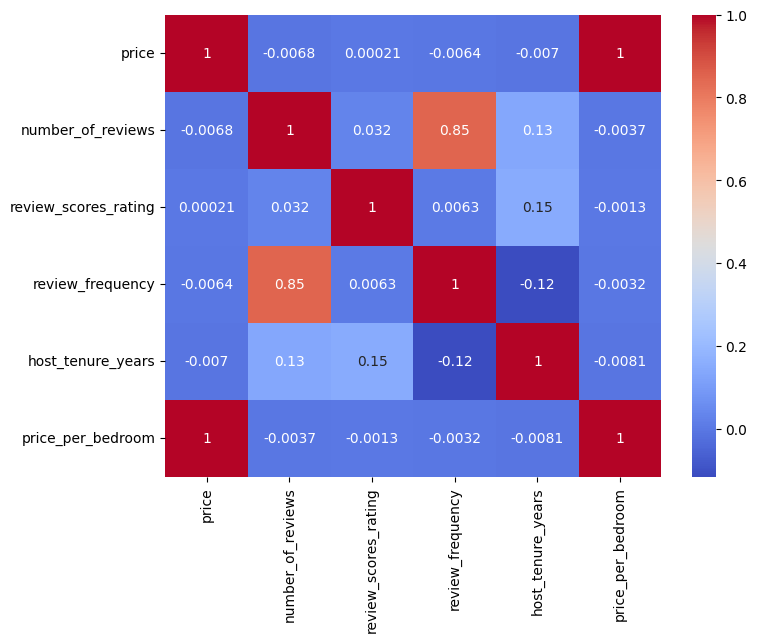

In [27]:
#Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()